In [1]:
# importing base libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
sns.set()

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# loading the datasets
train_df = pd.read_csv('/content/drive/MyDrive/twitter_training.csv')
test_df = pd.read_csv('/content/drive/MyDrive/twitter_test.csv')

# EDA

In [4]:
# displaying the first 5 rows of training data
train_df.head()

,2401,Borderlands,Positive,"im getting on borderlands and i will murder you all ,"
0,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
1,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
2,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
3,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...
4,2401,Borderlands,Positive,im getting into borderlands and i can murder y...


In [5]:
# displaying the first 5 rows of test data
test_df.head()

,3364,Facebook,Irrelevant,"I mentioned on Facebook that I was struggling for motivation to go for a run the other day, which has been translated by Tom’s great auntie as ‘Hayley can’t get out of bed’ and told to his grandma, who now thinks I’m a lazy, terrible person 🤣"
0,352,Amazon,Neutral,BBC News - Amazon boss Jeff Bezos rejects clai...
1,8312,Microsoft,Negative,@Microsoft Why do I pay for WORD when it funct...
2,4371,CS-GO,Negative,"CSGO matchmaking is so full of closet hacking,..."
3,4433,Google,Neutral,Now the President is slapping Americans in the...
4,6273,FIFA,Negative,Hi @EAHelp I’ve had Madeleine McCann in my cel...


In [6]:
# displaying some information about the dataset
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74681 entries, 0 to 74680
Data columns (total 4 columns):
 #   Column                                                 Non-Null Count  Dtype 
---  ------                                                 --------------  ----- 
 0   2401                                                   74681 non-null  int64 
 1   Borderlands                                            74681 non-null  object
 2   Positive                                               74681 non-null  object
 3   im getting on borderlands and i will murder you all ,  73995 non-null  object
dtypes: int64(1), object(3)
memory usage: 2.3+ MB


In [7]:
# displaying some information about the dataset
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 999 entries, 0 to 998
Data columns (total 4 columns):
 #   Column                                                                                                                                                                                                                                              Non-Null Count  Dtype 
---  ------                                                                                                                                                                                                                                              --------------  ----- 
 0   3364                                                                                                                                                                                                                                                999 non-null    int64 
 1   Facebook                                                                   

In [8]:
# fixing data header
train_df.columns = ['id', 'source','label' ,'tweet']
test_df.columns = ['id', 'source','label', 'tweet']
train_df.head()

,id,source,label,tweet
0,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
1,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
2,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
3,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...
4,2401,Borderlands,Positive,im getting into borderlands and i can murder y...


In [9]:
# dropping the id coulmn
train_df.drop('id', axis=1, inplace=True)
test_df.drop('id', axis=1, inplace=True)

In [10]:
train_df.head()

,source,label,tweet
0,Borderlands,Positive,I am coming to the borders and I will kill you...
1,Borderlands,Positive,im getting on borderlands and i will kill you ...
2,Borderlands,Positive,im coming on borderlands and i will murder you...
3,Borderlands,Positive,im getting on borderlands 2 and i will murder ...
4,Borderlands,Positive,im getting into borderlands and i can murder y...


In [11]:
# checking the shape of training and testing data
print("Training data shape:", train_df.shape)
print("Testing data shape:", test_df.shape)

Training data shape: (74681, 3)
Testing data shape: (999, 3)


In [12]:
# checking for null values
print("Null values in training data:\n", train_df.isnull().sum())
print("Null values in testing data:\n", test_df.isnull().sum())

Null values in training data:
 source      0
label       0
tweet     686
dtype: int64
Null values in testing data:
 source    0
label     0
tweet     0
dtype: int64


- so there is no missing values in the test data but there are 686 missing tweets in the training data

In [13]:
# checking for duplicates
print("Duplicate rows in training data:", train_df.duplicated().sum())
print("Duplicate rows in testing data:", test_df.duplicated().sum())

Duplicate rows in training data: 3621
Duplicate rows in testing data: 0


- also here the training data contains 3621 duplcated rows

In [14]:
# checking for label inconsistancy
print("Unique labels in training data:", train_df['label'].unique())
print("Unique labels in testing data:", test_df['label'].unique())

Unique labels in training data: ['Positive' 'Neutral' 'Negative' 'Irrelevant']
Unique labels in testing data: ['Neutral' 'Negative' 'Positive' 'Irrelevant']


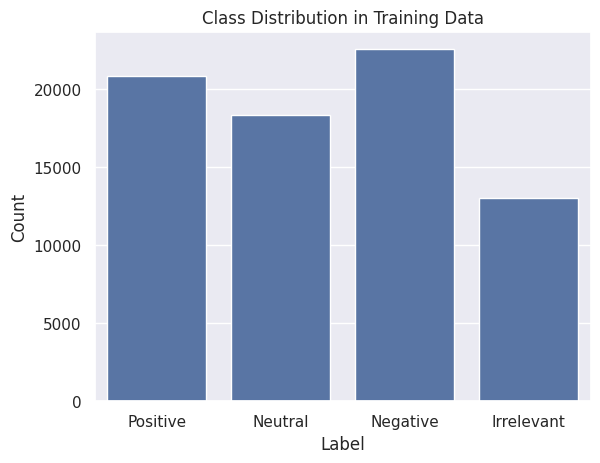

In [15]:
# checking class imbalance
sns.countplot(x='label', data=train_df)
plt.title("Class Distribution in Training Data")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()


# data cleaning

In [16]:
# getting red of the missing values
train_df.dropna(inplace=True)
train_df.reset_index(drop=True, inplace=True)
train_df.head()

,source,label,tweet
0,Borderlands,Positive,I am coming to the borders and I will kill you...
1,Borderlands,Positive,im getting on borderlands and i will kill you ...
2,Borderlands,Positive,im coming on borderlands and i will murder you...
3,Borderlands,Positive,im getting on borderlands 2 and i will murder ...
4,Borderlands,Positive,im getting into borderlands and i can murder y...


In [17]:
# getting red of the duplicates
train_df.drop_duplicates(inplace=True)
train_df.reset_index(drop=True, inplace=True)
train_df.head()

,source,label,tweet
0,Borderlands,Positive,I am coming to the borders and I will kill you...
1,Borderlands,Positive,im getting on borderlands and i will kill you ...
2,Borderlands,Positive,im coming on borderlands and i will murder you...
3,Borderlands,Positive,im getting on borderlands 2 and i will murder ...
4,Borderlands,Positive,im getting into borderlands and i can murder y...


# visualizations

In [18]:
# getting the length of every tweet
train_df['length'] = train_df['tweet'].str.split(' ').apply(len)
test_df['length'] = test_df['tweet'].str.split(' ').apply(len)
train_df.head()


,source,label,tweet,length
0,Borderlands,Positive,I am coming to the borders and I will kill you...,12
1,Borderlands,Positive,im getting on borderlands and i will kill you ...,10
2,Borderlands,Positive,im coming on borderlands and i will murder you...,10
3,Borderlands,Positive,im getting on borderlands 2 and i will murder ...,12
4,Borderlands,Positive,im getting into borderlands and i can murder y...,10


In [19]:
# sort the dataframe based on the length and display the first 10 tweets
sorted_train = train_df.sort_values(by='length')
sorted_train[['tweet', 'length']].head(10)


,tweet,length
64403,there,1
10,was,1
40196,I,1
70897,were,1
47027,What,1
182,why,1
192,I,1
40075,that,1
40762,Really,1
57852,Wow...,1


In [20]:
# sort the dataframe based on the length and display the last 10 tweets
sorted_train = train_df.sort_values(by='length')
sorted_train[['tweet', 'length']].tail(10)

,tweet,length
58285,(PC) Come Vibe With Me. Messing Around in GTA!...,163
8112,I REALLY HAVE THE OVERWATCH RN GAME. SEA SEA S...,166
64701,@ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ ...,175
65160,"When fear is raised that ""punk-2077"" may be po...",189
49456,There was a meeting with the interns on their ...,190
65207,"I'm a little disappointed, but my schedule app...",194
41417,# # # # # # # # # # # # # # # # # # # # # # # ...,198
30497,= = = = = = = = = = = = = = = = = = = = = = = ...,198
1752,_ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ ...,198
9907,_ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ ...,198


In [21]:
for tweet in sorted_train['tweet'].tail(10):
    print(tweet)
    print('__________________________________________________________________________________________________________')

(PC) Come Vibe With Me. Messing Around in GTA!!!!!!!!!!!!!!!!!!!!!!!!!!!!! _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _
__________________________________________________________________________________________________________
I REALLY HAVE THE OVERWATCH RN GAME. SEA SEA SEA SEA SEA SEA SEA SEA SEA SEA SEA SEA SEA SEA SEA SEA SEA SEA SEA SEE E E E E E E E E E E E E E E E E E E E E E E E E E E E E E E E E E E E E E E E E E E E E E E E E E E E E E E E E E E E E E E E E E E E E E E E E E E E E E E E E E E E E E E E E E E E E E E E E E E E E E E E E E E E E E E E E E E E E E E E E E E E E E E E E E E E E E E E E E E E
__________________________________________________________________________________________________________
@ _ _ _ 

In [22]:
# displaying the highest length
print("Maximum tweet length in training data:", train_df['length'].max())
print("Maximum tweet length in testing data:", test_df['length'].max())


Maximum tweet length in training data: 198
Maximum tweet length in testing data: 57


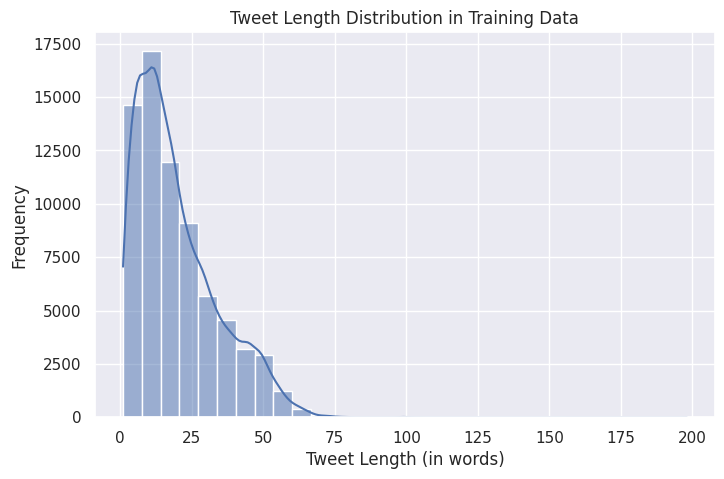

In [23]:
# displaying the highest length
plt.figure(figsize=(8,5))
sns.histplot(train_df['length'], bins=30, kde=True)
plt.title("Tweet Length Distribution in Training Data")
plt.xlabel("Tweet Length (in words)")
plt.ylabel("Frequency")
plt.show()

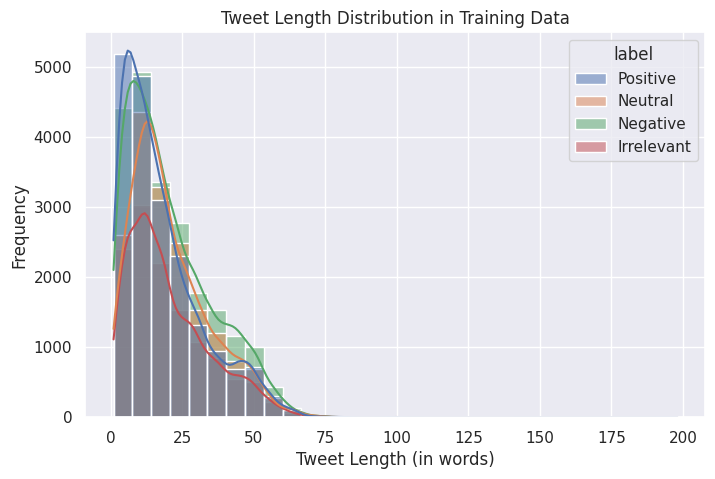

In [24]:
# displaying the highest length
plt.figure(figsize=(8,5))
sns.histplot(data = train_df , x='length', bins=30, kde=True , hue='label')
plt.title("Tweet Length Distribution in Training Data")
plt.xlabel("Tweet Length (in words)")
plt.ylabel("Frequency")
plt.show()

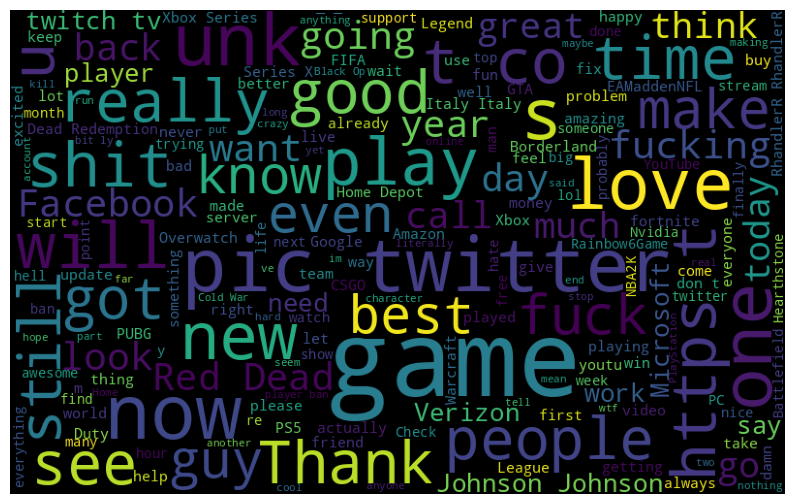

In [25]:
# displaying the most frequent words using wrodcloud
from wordcloud import WordCloud
all_words = ' '.join([text for text in train_df['tweet']])
wordcloud = WordCloud(width=800, height=500, random_state=21, max_font_size=110).generate(all_words)
plt.figure(figsize=(10, 7))
plt.imshow(wordcloud)
plt.axis('off')
plt.show()


# preprocessing

In [26]:
# cleaning the tweets using regex
import re
def clean_tweet(tweet):
    tweet = re.sub(r'http\S+|www\S+|https\S+', '', tweet, flags=re.MULTILINE)
    tweet = re.sub(r'\@\w+|\#','', tweet)
    emoji_pattern = re.compile(
        "["
        "\U0001F600-\U0001F64F"
        "\U0001F300-\U0001F5FF"
        "\U0001F680-\U0001F6FF"
        "\U0001F1E0-\U0001F1FF"
        "\U00002702-\U000027B0"
        "\U000024C2-\U0001F251"
        "]+",
        flags=re.UNICODE
    )
    tweet = emoji_pattern.sub(r'', tweet)
    tweet = re.sub(r'[^A-Za-z0-9\s]', '', tweet)

    tweet = tweet.lower()
    pattern = r'\b(\w+)(?:\W+\1\b)+'
    tweet = re.sub(pattern, r'\1', tweet, flags=re.IGNORECASE)
    return tweet
train_df['cleaned_tweet'] = train_df['tweet'].apply(clean_tweet)
test_df['cleaned_tweet'] = test_df['tweet'].apply(clean_tweet)
sorted_train['tweet'] = sorted_train['tweet'].apply(clean_tweet)

In [27]:
# displaying the first 10 rows after cleaning
sorted_train[['tweet', 'length']].head(10)

,tweet,length
64403,there,1
10,was,1
40196,i,1
70897,were,1
47027,what,1
182,why,1
192,i,1
40075,that,1
40762,really,1
57852,wow,1


In [28]:
# displaying the last 10 rows after cleaning
for tweet in sorted_train['tweet'].tail(10):
    print(tweet)
    print('__________________________________________________________________________________________________________')

pc come vibe with me messing around in gta                                                                                                                                                          
__________________________________________________________________________________________________________
i really have the overwatch rn game sea see e
__________________________________________________________________________________________________________
                                                                                                                                                                              
__________________________________________________________________________________________________________
when fear is raised that punk2077 may be postponed for several years which i hope will not happen but here is another powerful blow to the bollocks in 2020                                                                                                          

In [29]:
# getting red of the empty tweets after preprocessing
train_df = train_df[train_df['cleaned_tweet'].str.strip() != '']
train_df.reset_index(drop=True, inplace=True)

In [30]:
# getting red of tweets with length less than 4
train_df = train_df[train_df['length'] >= 4]
train_df.reset_index(drop=True, inplace=True)

In [31]:
# tokenizing the tweets and remove stopwords using nltk
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))
def nltk_tokenize_and_remove_stopwords(text):
    tokens = text.split()
    filtered_tokens = [word for word in tokens if word.lower() not in stop_words]
    return ' '.join(filtered_tokens)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [32]:
# getting the number of unique words in the tweets
unique_words = set()
for tweet in train_df['cleaned_tweet']:
    for word in tweet.split():
        unique_words.add(word)
print("Number of unique words in training data:", len(unique_words))

Number of unique words in training data: 39322


In [33]:
# encoding the tweets using tf-idf
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf_vectorizer = TfidfVectorizer(max_features=5000 , ngram_range=(1,2))
X_train = tfidf_vectorizer.fit_transform(train_df['cleaned_tweet']).toarray()
X_test = tfidf_vectorizer.transform(test_df['cleaned_tweet']).toarray()

In [34]:
# encoding the labels
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_train = le.fit_transform(train_df['label'])
y_test = le.transform(test_df['label'])

# model


In [35]:
# build a naive base for multiclass classification
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
model = MultinomialNB()
model.fit(X_train, y_train)
y_train_pred = model.predict(X_train)
print(classification_report(y_train, y_train_pred))

              precision    recall  f1-score   support

           0       0.75      0.38      0.51     11640
           1       0.64      0.82      0.72     19990
           2       0.67      0.57      0.61     16473
           3       0.64      0.75      0.69     17688

    accuracy                           0.66     65791
   macro avg       0.68      0.63      0.63     65791
weighted avg       0.67      0.66      0.65     65791



In [84]:
# test on test data
y_test_pred = model.predict(X_test)
print(classification_report(y_test, y_test_pred))

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step
              precision    recall  f1-score   support

           0       0.66      0.50      0.57       171
           1       0.70      0.81      0.75       266
           2       0.67      0.62      0.65       285
           3       0.70      0.77      0.73       277

    accuracy                           0.69       999
   macro avg       0.69      0.67      0.67       999
weighted avg       0.69      0.69      0.68       999



# second part
- encoding using Bert
- use lstm for model


In [36]:
# loading bert
from transformers import AutoTokenizer, AutoModel
import torch

tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
model = AutoModel.from_pretrained("bert-base-uncased")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

In [37]:
from tqdm import tqdm

# Put model in evaluation mode
model.eval()

# Optional: Use GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# Function to get mean pooled embedding
def get_embedding(text):
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True).to(device)
    with torch.no_grad():
        outputs = model(**inputs)
    embedding = outputs.last_hidden_state.mean(dim=1).squeeze().cpu().numpy()
    return embedding

In [38]:
# Apply to DataFrame column
tqdm.pandas()  # for progress bar
X_train_embeddings = train_df["cleaned_tweet"].progress_apply(get_embedding)
X_test_embeddings = test_df["cleaned_tweet"].progress_apply(get_embedding)

100%|██████████| 999/999 [00:08<00:00, 123.87it/s]


In [85]:
from keras.models import Sequential
from keras.layers import LSTM, Bidirectional, Dense, Dropout, BatchNormalization, Reshape
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
from keras.optimizers import Adam
from sklearn.preprocessing import StandardScaler
import numpy as np

# --- Scale embeddings ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_embeddings_array)

# --- Reshape embeddings for LSTM input ---
X_train_reshaped = np.expand_dims(X_train_scaled, axis=1)  # shape: (samples, timesteps=1, features)

# --- Model definition ---
model = Sequential([
    Bidirectional(LSTM(256, return_sequences=False, dropout=0.4, recurrent_dropout=0.3),
                  input_shape=(1, X_train_scaled.shape[1])),
    BatchNormalization(),

    Dense(128, activation='relu', kernel_regularizer='l2'),
    Dropout(0.5),
    Dense(64, activation='relu', kernel_regularizer='l2'),
    Dropout(0.4),

    Dense(4, activation='softmax')
])

# --- Compile ---
optimizer = Adam(learning_rate=1e-4)
model.compile(loss='sparse_categorical_crossentropy', optimizer=optimizer, metrics=['accuracy'])

# --- Callbacks ---
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, verbose=1)

# --- Train ---
history = model.fit(
    X_train_reshaped, y_train,
    epochs=20,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
823/823 ━━━━━━━━━━━━━━━━━━━━ 24s 22ms/step - accuracy: 0.3251 - loss: 4.4293 - val_accuracy: 0.5557 - val_loss: 3.2998 - learning_rate: 1.0000e-04
Epoch 2/20
823/823 ━━━━━━━━━━━━━━━━━━━━ 19s 20ms/step - accuracy: 0.4483 - loss: 3.2532 - val_accuracy: 0.5792 - val_loss: 2.6126 - learning_rate: 1.0000e-04
Epoch 3/20
823/823 ━━━━━━━━━━━━━━━━━━━━ 17s 21ms/step - accuracy: 0.5024 - loss: 2.5532 - val_accuracy: 0.5822 - val_loss: 2.0778 - learning_rate: 1.0000e-04
Epoch 4/20
823/823 ━━━━━━━━━━━━━━━━━━━━ 20s 21ms/step - accuracy: 0.5406 - loss: 2.0274 - val_accuracy: 0.5854 - val_loss: 1.7023 - learning_rate: 1.0000e-04
Epoch 5/20
823/823 ━━━━━━━━━━━━━━━━━━━━ 17s 21ms/step - accuracy: 0.5675 - loss: 1.6495 - val_accuracy: 0.5759 - val_loss: 1.4668 - learning_rate: 1.0000e-04
Epoch 6/20
823/823 ━━━━━━━━━━━━━━━━━━━━ 18s 22ms/step - accuracy: 0.5888 - loss: 1.3933 - val_accuracy: 0.5788 - val_loss: 1.3208 - learning_rate: 1.0000e-04
Epoch 7/20
823/823 ━━━━━━━━━━━━━━━━━━━━ 17s 20ms/ste

In [88]:
# test the model for overfitting on the train data
X_train_reshaped = np.expand_dims(X_train_embeddings_array, axis=1)
test_loss, test_acc = model.evaluate(X_train_reshaped, y_train)
print('Test accuracy:', test_acc)

2056/2056 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.5563 - loss: 1.2672
Test accuracy: 0.5518231987953186


In [91]:
# test the model for underfitting on the test data

X_test_reshaped = np.expand_dims(X_test_embeddings_array, axis=1)
test_loss, test_acc = model.evaluate(X_test_reshaped, y_test)
print('Test accuracy:', test_acc)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5690 - loss: 1.2387
Test accuracy: 0.5585585832595825
